In [ ]:
# =========================================
# 1 Imports
# =========================================
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import ResNet50, EfficientNetB7
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import random
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from skimage.segmentation import felzenszwalb
from skimage import measure
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import cv2
import pandas as pd

In [ ]:
# =========================================
# 2 Data path
# =========================================
DATASET_PATH = DATASET_PATH = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", DATASET_PATH)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
# =========================================
# 3 Dataset Paths & Parameters
# =========================================
TRAIN_DIR = DATASET_PATH + "/Training"
TEST_DIR = DATASET_PATH + "/Testing"

IMG_SIZE = (380, 380)
BATCH_SIZE = 16
NUM_CLASSES = 4
EPOCHS = 20

In [ ]:
# =========================================
# 4 Data Preprocessing & Augmentation
# =========================================
# Here we prepare the Data Augmentation more strongly because MRI images benefit from diversification
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)


# Training Data Generator
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Validation Data Generator
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)
# Test Data Generator (without Augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
# =========================================
# 5 Base Models (Transfer Learning)
# =========================================
# Download ResNet50 and EfficientNetB7 without the top
resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
efficientnet = EfficientNetB7(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Here we allow fine-tuning but freeze the first layers to preserve the general features
resnet.trainable = True
efficientnet.trainable = True

# Freezing the first part of ResNet50
for layer in resnet.layers[:100]:
    layer.trainable = False

# Freezing the first part of EfficientNetB7
for layer in efficientnet.layers[:400]:
    layer.trainable = False


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
# =========================================
# 6 Ensemble Model Architecture (FIXED)
# =========================================
# Here we build the Ensemble model with improved integration between the two models

input_layer = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# ResNet50 Features
resnet_features = resnet(input_layer)
resnet_features = layers.GlobalAveragePooling2D()(resnet_features)
resnet_features = layers.Dense(512, activation='relu')(resnet_features)

# EfficientNet-B7 Features
eff_features = efficientnet(input_layer)
eff_features = layers.GlobalAveragePooling2D()(eff_features)
eff_features = layers.Dense(512, activation='relu')(eff_features)

# Fusion Layer
fusion = layers.Concatenate()([eff_features, resnet_features])

# Fully Connected Head
x = layers.BatchNormalization()(fusion)

# A strong Dense layer with Regularization to reduce Overfitting
x = layers.Dense(
    256,
    activation='relu',
    kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)
)(x)

# Dropout to reduce overfitting
x = layers.Dropout(0.5)(x)

# An additional layer to improve representation
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)

# Final director by number of classes
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

# Building the final model
model = models.Model(inputs=input_layer, outputs=output)

print("Trainable layers:", sum([1 for l in model.layers if l.trainable]))

Trainable layers: 14


In [ ]:
# =========================================
# 7 Compile Model (Fine-Tuning)
# =========================================
model.compile(
    optimizer=AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# =========================================
# 8 Callbacks
# =========================================
lr_callback = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

# Save the best model based on val_accuracy
checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Early stopping to avoid overfitting
earlystop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# Calculating class_weights to balance the classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


In [ ]:
# =========================================
# 9 Training
# =========================================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[lr_callback, checkpoint, earlystop],
    class_weight=class_weights
)

Epoch 1/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3975 - loss: 1.7336
Epoch 1: val_accuracy improved from None to 0.48750, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
280/280 ━━━━━━━━━━━━━━━━━━━━ 635s 1s/step - accuracy: 0.4359 - loss: 1.5446 - val_accuracy: 0.4875 - val_loss: 1.2942 - learning_rate: 1.0000e-04
Epoch 2/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4940 - loss: 1.3415
Epoch 2: val_accuracy improved from 0.48750 to 0.55982, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
280/280 ━━━━━━━━━━━━━━━━━━━━ 372s 1s/step - accuracy: 0.5183 - loss: 1.2654 - val_accuracy: 0.5598 - val_loss: 1.1444 - learning_rate: 1.0000e-04
Epoch 3/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5864 - loss: 1.1278
Epoch 3: val_accuracy improved from 0.55982 to 0.64018, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
280/280 ━━━━━━━━━━━━━━━━━━━━ 378s 1s/step - accuracy: 0.5908 - loss: 1.1101 - val_accuracy: 0.6402 - val_loss: 0.9476 - learning_rate: 1.0000e-04
Epoch 4/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6568 - loss: 0.9803
Epoch 4: val_accuracy improved from 0.64018 to 0.74375, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
280/280 ━━━━━━━━━━━━━━━━━━━━ 370s 1s/step - accuracy: 0.6692 - loss: 0.9362 - val_accuracy: 0.7437 - val_loss: 0.7573 - learning_rate: 1.0000e-04
Epoch 5/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7135 - loss: 0.8552
Epoch 5: val_accuracy improved from 0.74375 to 0.80625, saving model to best_model.h5


...


Epoch 14: finished saving model to best_model.h5
280/280 ━━━━━━━━━━━━━━━━━━━━ 373s 1s/step - accuracy: 0.9333 - loss: 0.3166 - val_accuracy: 0.9518 - val_loss: 0.2467 - learning_rate: 1.0000e-04
Epoch 15/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9387 - loss: 0.3223
Epoch 15: val_accuracy improved from 0.95179 to 0.95357, saving model to best_model.h5



Epoch 15: finished saving model to best_model.h5
280/280 ━━━━━━━━━━━━━━━━━━━━ 398s 1s/step - accuracy: 0.9402 - loss: 0.3059 - val_accuracy: 0.9536 - val_loss: 0.2504 - learning_rate: 1.0000e-04
Epoch 16/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9395 - loss: 0.2802
Epoch 16: val_accuracy improved from 0.95357 to 0.96161, saving model to best_model.h5



Epoch 16: finished saving model to best_model.h5
280/280 ━━━━━━━━━━━━━━━━━━━━ 413s 1s/step - accuracy: 0.9371 - loss: 0.2947 - val_accuracy: 0.9616 - val_loss: 0.2236 - learning_rate: 1.0000e-04
Epoch 17/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9440 - loss: 0.2887
Epoch 17: val_accuracy improved from 0.96161 to 0.96607, saving model to best_model.h5



Epoch 17: finished saving model to best_model.h5
280/280 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.9413 - loss: 0.2910 - val_accuracy: 0.9661 - val_loss: 0.2098 - learning_rate: 1.0000e-04
Epoch 18/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9512 - loss: 0.2845
Epoch 18: val_accuracy did not improve from 0.96607
280/280 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.9480 - loss: 0.2926 - val_accuracy: 0.9625 - val_loss: 0.2199 - learning_rate: 1.0000e-04
Epoch 19/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9561 - loss: 0.2552
Epoch 19: val_accuracy did not improve from 0.96607
280/280 ━━━━━━━━━━━━━━━━━━━━ 356s 1s/step - accuracy: 0.9551 - loss: 0.2539 - val_accuracy: 0.9607 - val_loss: 0.2349 - learning_rate: 1.0000e-04
Epoch 20/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9513 - loss: 0.2742
Epoch 20: val_accuracy improved from 0.96607 to 0.97500, saving model to best_model.h5



Epoch 20: finished saving model to best_model.h5
280/280 ━━━━━━━━━━━━━━━━━━━━ 408s 1s/step - accuracy: 0.9551 - loss: 0.2555 - val_accuracy: 0.9750 - val_loss: 0.1897 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 20.


In [ ]:
# =========================================
# 10 Evaluation on Test Set
# =========================================
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

100/100 ━━━━━━━━━━━━━━━━━━━━ 51s 508ms/step - accuracy: 0.9350 - loss: 0.3888
Test Accuracy: 0.9350
Test Loss: 0.3888


In [ ]:
# =========================================
# 11 Detailed Metrics
# =========================================
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
class_labels = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred_classes, target_names=class_labels))

100/100 ━━━━━━━━━━━━━━━━━━━━ 77s 503ms/step
              precision    recall  f1-score   support

      glioma       0.97      0.81      0.89       400
  meningioma       0.90      0.94      0.92       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.94      0.99      0.97       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.93      1600
weighted avg       0.94      0.94      0.93      1600



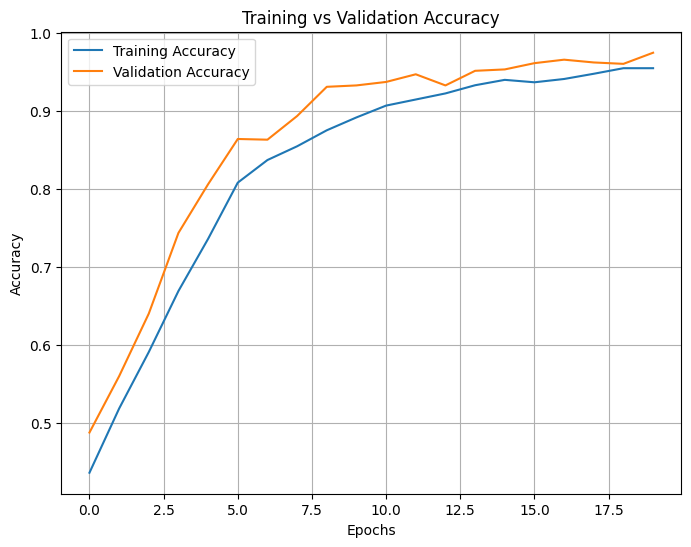

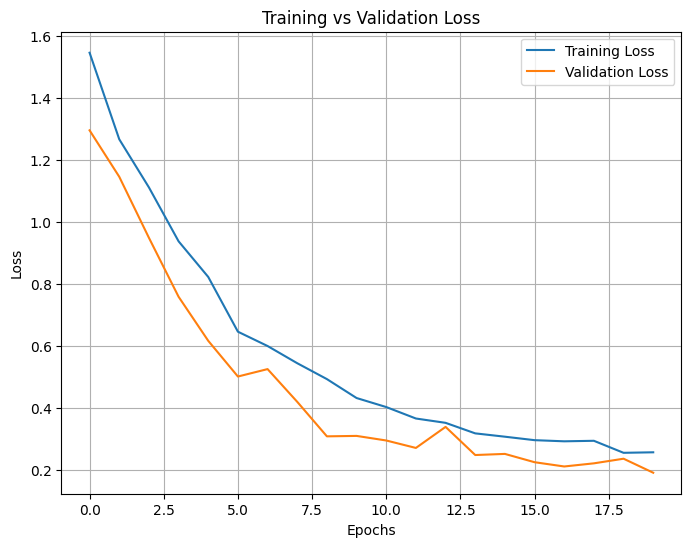

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
lrs = history.history.get("lr", None)

if lrs:
    plt.figure(figsize=(8,6))
    plt.plot(lrs)
    plt.title("Learning Rate Schedule")
    plt.xlabel("Epochs")
    plt.ylabel("Learning Rate")
    plt.grid(True)
    plt.show()
else:
    print("Learning rate history not found in callbacks.")


Learning rate history not found in callbacks.


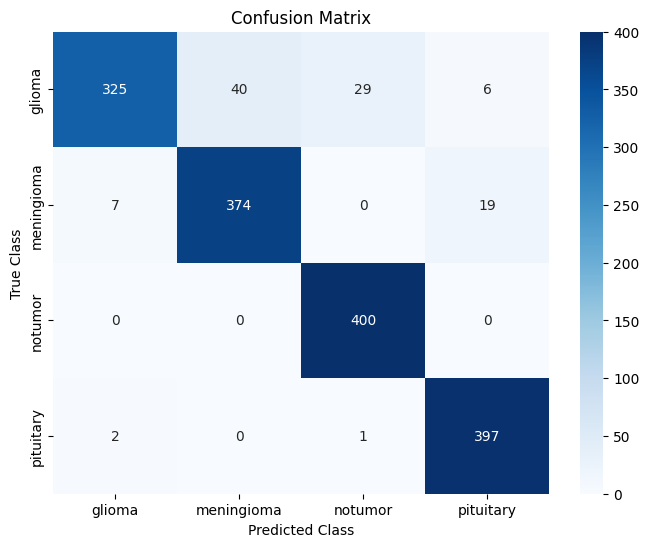

In [ ]:
# confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

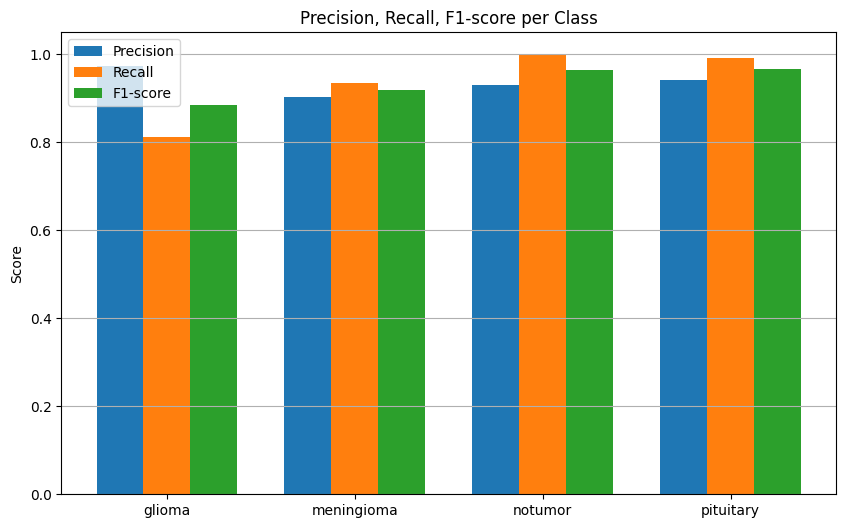

In [ ]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred_classes, labels=[0,1,2,3]
)

metrics = {
    "Class": class_labels,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

plt.figure(figsize=(10,6))
x = np.arange(len(class_labels))
width = 0.25

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-score')

plt.xticks(x, class_labels)
plt.title("Precision, Recall, F1-score per Class")
plt.ylabel("Score")
plt.legend()
plt.grid(axis='y')
plt.show()


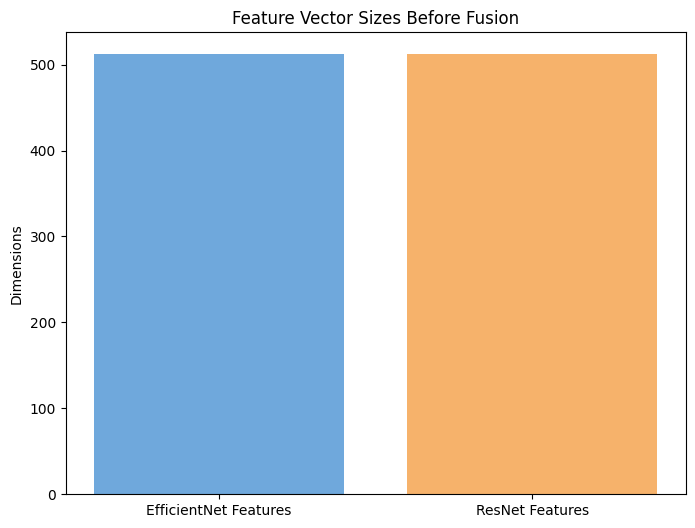

In [ ]:
plt.figure(figsize=(8,6))
plt.bar(["EfficientNet Features", "ResNet Features"], [512, 512], color=["#6fa8dc", "#f6b26b"])
plt.title("Feature Vector Sizes Before Fusion")
plt.ylabel("Dimensions")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 34s 34s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


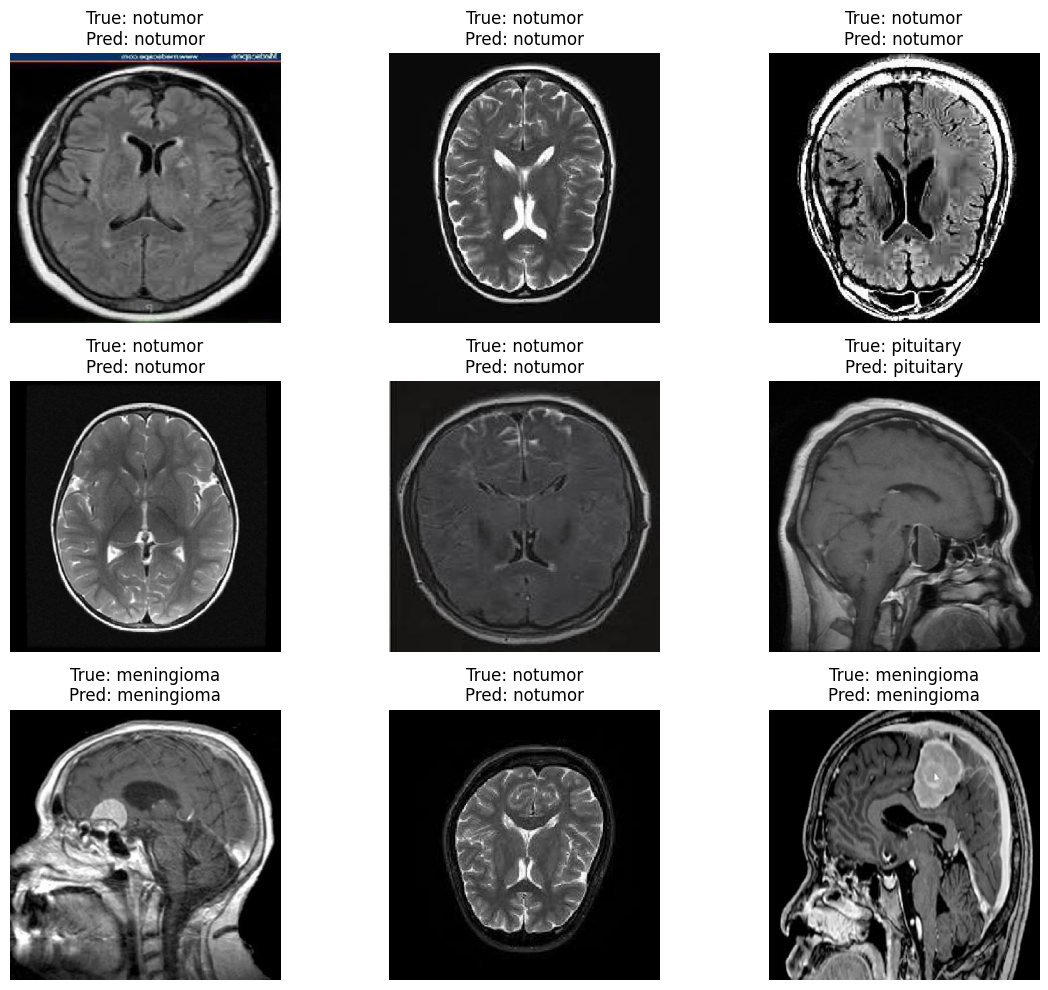

In [ ]:
plt.figure(figsize=(12,10))

# Number of images in test_generator
num_images = len(test_generator.filenames)

for i in range(9):
# Select a random image
    idx = random.randint(0, num_images - 1)

# Download the image directly from the path
    img_path = test_generator.filepaths[idx]
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0

# Preparing the image for prediction
    img_batch = np.expand_dims(img_array, axis=0)
    pred = model.predict(img_batch)
    pred_class = np.argmax(pred)

# Getting the real label
    true_class = y_true[idx]

# Drawing
    plt.subplot(3,3,i+1)
    plt.imshow(img_array)
    plt.title(f"True: {class_labels[true_class]}\nPred: {class_labels[pred_class]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


/tmp/ipykernel_620/3896786547.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


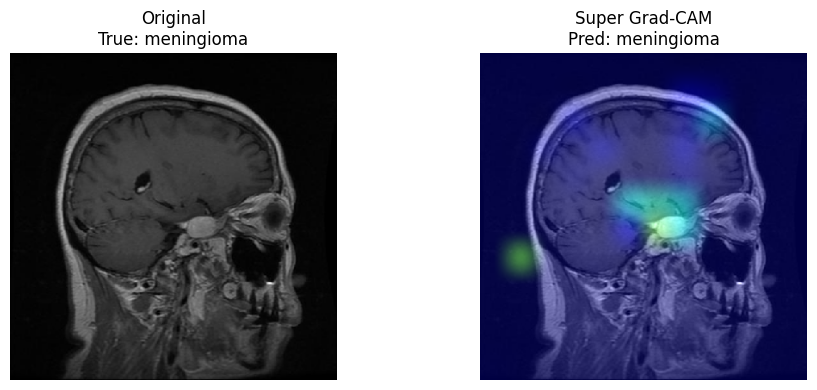

In [ ]:
# =========================================
# 12 Model Explanation Using Super Grad-CAM
# =========================================
import matplotlib.cm as cm

LAST_CONV_LAYER_RESNET = "conv5_block3_out"
LAST_CONV_LAYER_EFF = "top_conv"  # EfficientNetB7 last conv layer

def get_branch(model, name_keyword):
    for layer in model.layers:
        if name_keyword.lower() in layer.name.lower():
            return layer
    raise ValueError(f"{name_keyword} branch not found in the model.")

def make_gradcam_heatmap_branch(img_array, branch, last_conv_layer_name, class_index=None):
    last_conv_layer = branch.get_layer(last_conv_layer_name)
    grad_model = tf.keras.models.Model(
        inputs=branch.input,
        outputs=[last_conv_layer.output, branch.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array, training=False)

        # Global Average Pooling if preds are 4D
        if len(preds.shape) == 4:
            preds_gap = tf.reduce_mean(preds, axis=(1, 2))
        else:
            preds_gap = preds

        if class_index is None:
            class_index = tf.argmax(preds_gap[0])
        class_channel = preds_gap[:, class_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8
    return heatmap.numpy()

def overlay_heatmap(img_array_255, heatmap, alpha=0.5):
    heatmap = np.uint8(255*heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img_array_255.shape[1], img_array_255.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)
    superimposed = img_array_255 + jet_heatmap*alpha
    superimposed = np.clip(superimposed, 0, 255).astype("uint8")
    return superimposed


# Select a random test image
idx = random.randint(0, len(test_generator.filepaths)-1)
img_path = test_generator.filepaths[idx]
true_class = y_true[idx]

img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
img_batch = np.expand_dims(img_array, axis=0)

# Predict class
pred = model.predict(img_batch)
pred_class = np.argmax(pred[0])

# Get branches
resnet_branch = get_branch(model, "resnet")
eff_branch = get_branch(model, "efficientnet")

# Compute Grad-CAM for both branches
heatmap_resnet = make_gradcam_heatmap_branch(img_batch, resnet_branch, LAST_CONV_LAYER_RESNET, class_index=pred_class)
heatmap_eff = make_gradcam_heatmap_branch(img_batch, eff_branch, LAST_CONV_LAYER_EFF, class_index=pred_class)

# Combine heatmaps (average)
heatmap_super = (heatmap_resnet + heatmap_eff) / 2

# Overlay
original_uint8 = (img_array*255).astype("uint8")
gradcam_super_img = overlay_heatmap(original_uint8, heatmap_super, alpha=0.5)

# Display
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(original_uint8)
plt.title(f"Original\nTrue: {class_labels[true_class]}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gradcam_super_img)
plt.title(f"Super Grad-CAM\nPred: {class_labels[pred_class]}")
plt.axis("off")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


/tmp/ipykernel_620/3896786547.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


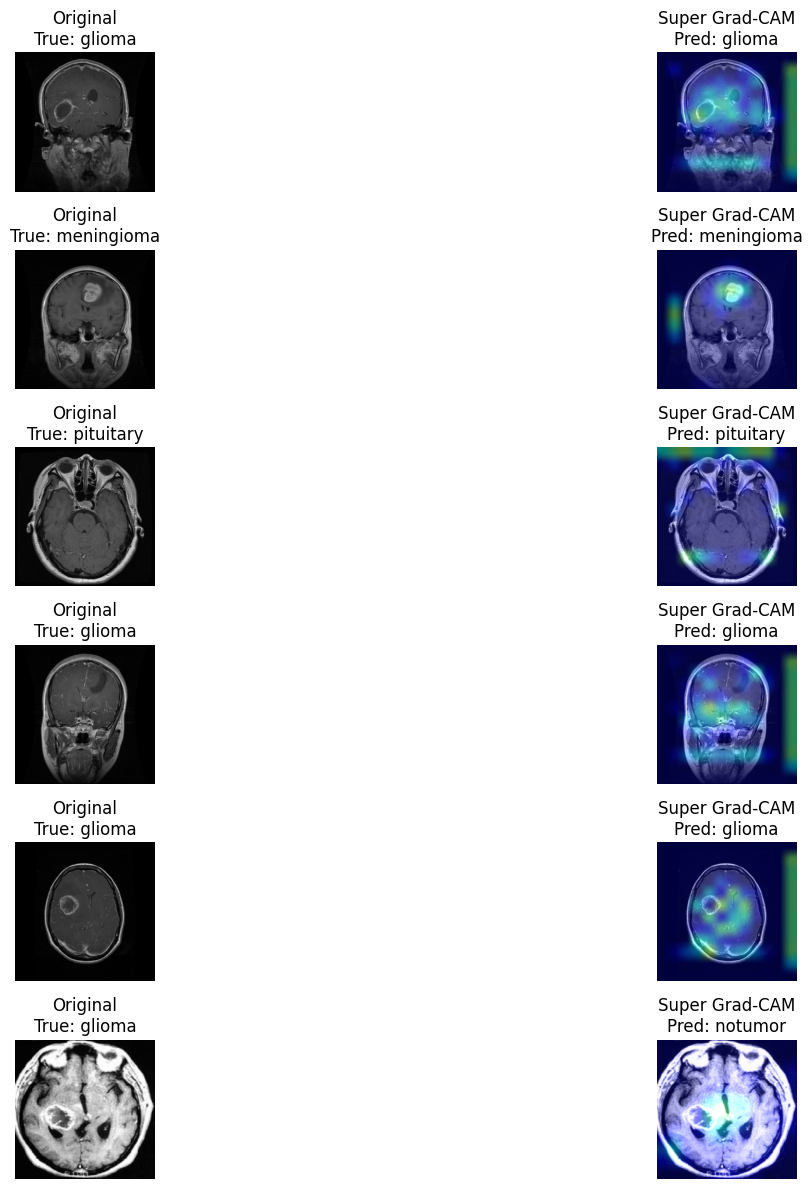

In [ ]:
# Display multiple Super Grad-CAM results
NUM_IMAGES = 6
resnet_branch = get_branch(model, "resnet")
eff_branch = get_branch(model, "efficientnet")

plt.figure(figsize=(18, 12))

for i in range(NUM_IMAGES):
    idx = random.randint(0, len(test_generator.filepaths)-1)
    img_path = test_generator.filepaths[idx]
    true_class = y_true[idx]

    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_batch)
    pred_class = np.argmax(pred[0])

    heatmap_resnet = make_gradcam_heatmap_branch(img_batch, resnet_branch, LAST_CONV_LAYER_RESNET, class_index=pred_class)
    heatmap_eff = make_gradcam_heatmap_branch(img_batch, eff_branch, LAST_CONV_LAYER_EFF, class_index=pred_class)
    heatmap_super = (heatmap_resnet + heatmap_eff) / 2

    original_uint8 = (img_array*255).astype("uint8")
    gradcam_super_img = overlay_heatmap(original_uint8, heatmap_super, alpha=0.5)

    plt.subplot(NUM_IMAGES, 2, 2*i+1)
    plt.imshow(original_uint8)
    plt.title(f"Original\nTrue: {class_labels[true_class]}")
    plt.axis("off")

    plt.subplot(NUM_IMAGES, 2, 2*i+2)
    plt.imshow(gradcam_super_img)
    plt.title(f"Super Grad-CAM\nPred: {class_labels[pred_class]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

File: Te-pi_192.jpg
True label:  pituitary
Predicted:   pituitary (100.0%)
Top regions:
  Region 1 (superpixel 52): influence 6.8% - priority low
  Region 2 (superpixel 35): influence 6.7% - priority low
  Region 3 (superpixel 40): influence 4.3% - priority low
  Region 4 (superpixel 56): influence 3.6% - priority low
  Region 5 (superpixel 36): influence 3.2% - priority low
File: Te-me_74.jpg
True label:  meningioma
Predicted:   meningioma (100.0%)
Top regions:
  Region 1 (superpixel 34): influence 15.3% - priority high
  Region 2 (superpixel 27): influence 12.8% - priority medium
  Region 3 (superpixel 24): influence 9.3% - priority medium
  Region 4 (superpixel 39): influence 6.5% - priority low
  Region 5 (superpixel 40): influence 5.7% - priority low
File: Te-gl_152.jpg
True label:  glioma
Predicted:   glioma (100.0%)
Top regions:
  Region 1 (superpixel 69): influence 9.8% - priority medium
  Region 2 (superpixel 58): influence 7.0% - priority low
  Region 3 (superpixel 12): influ

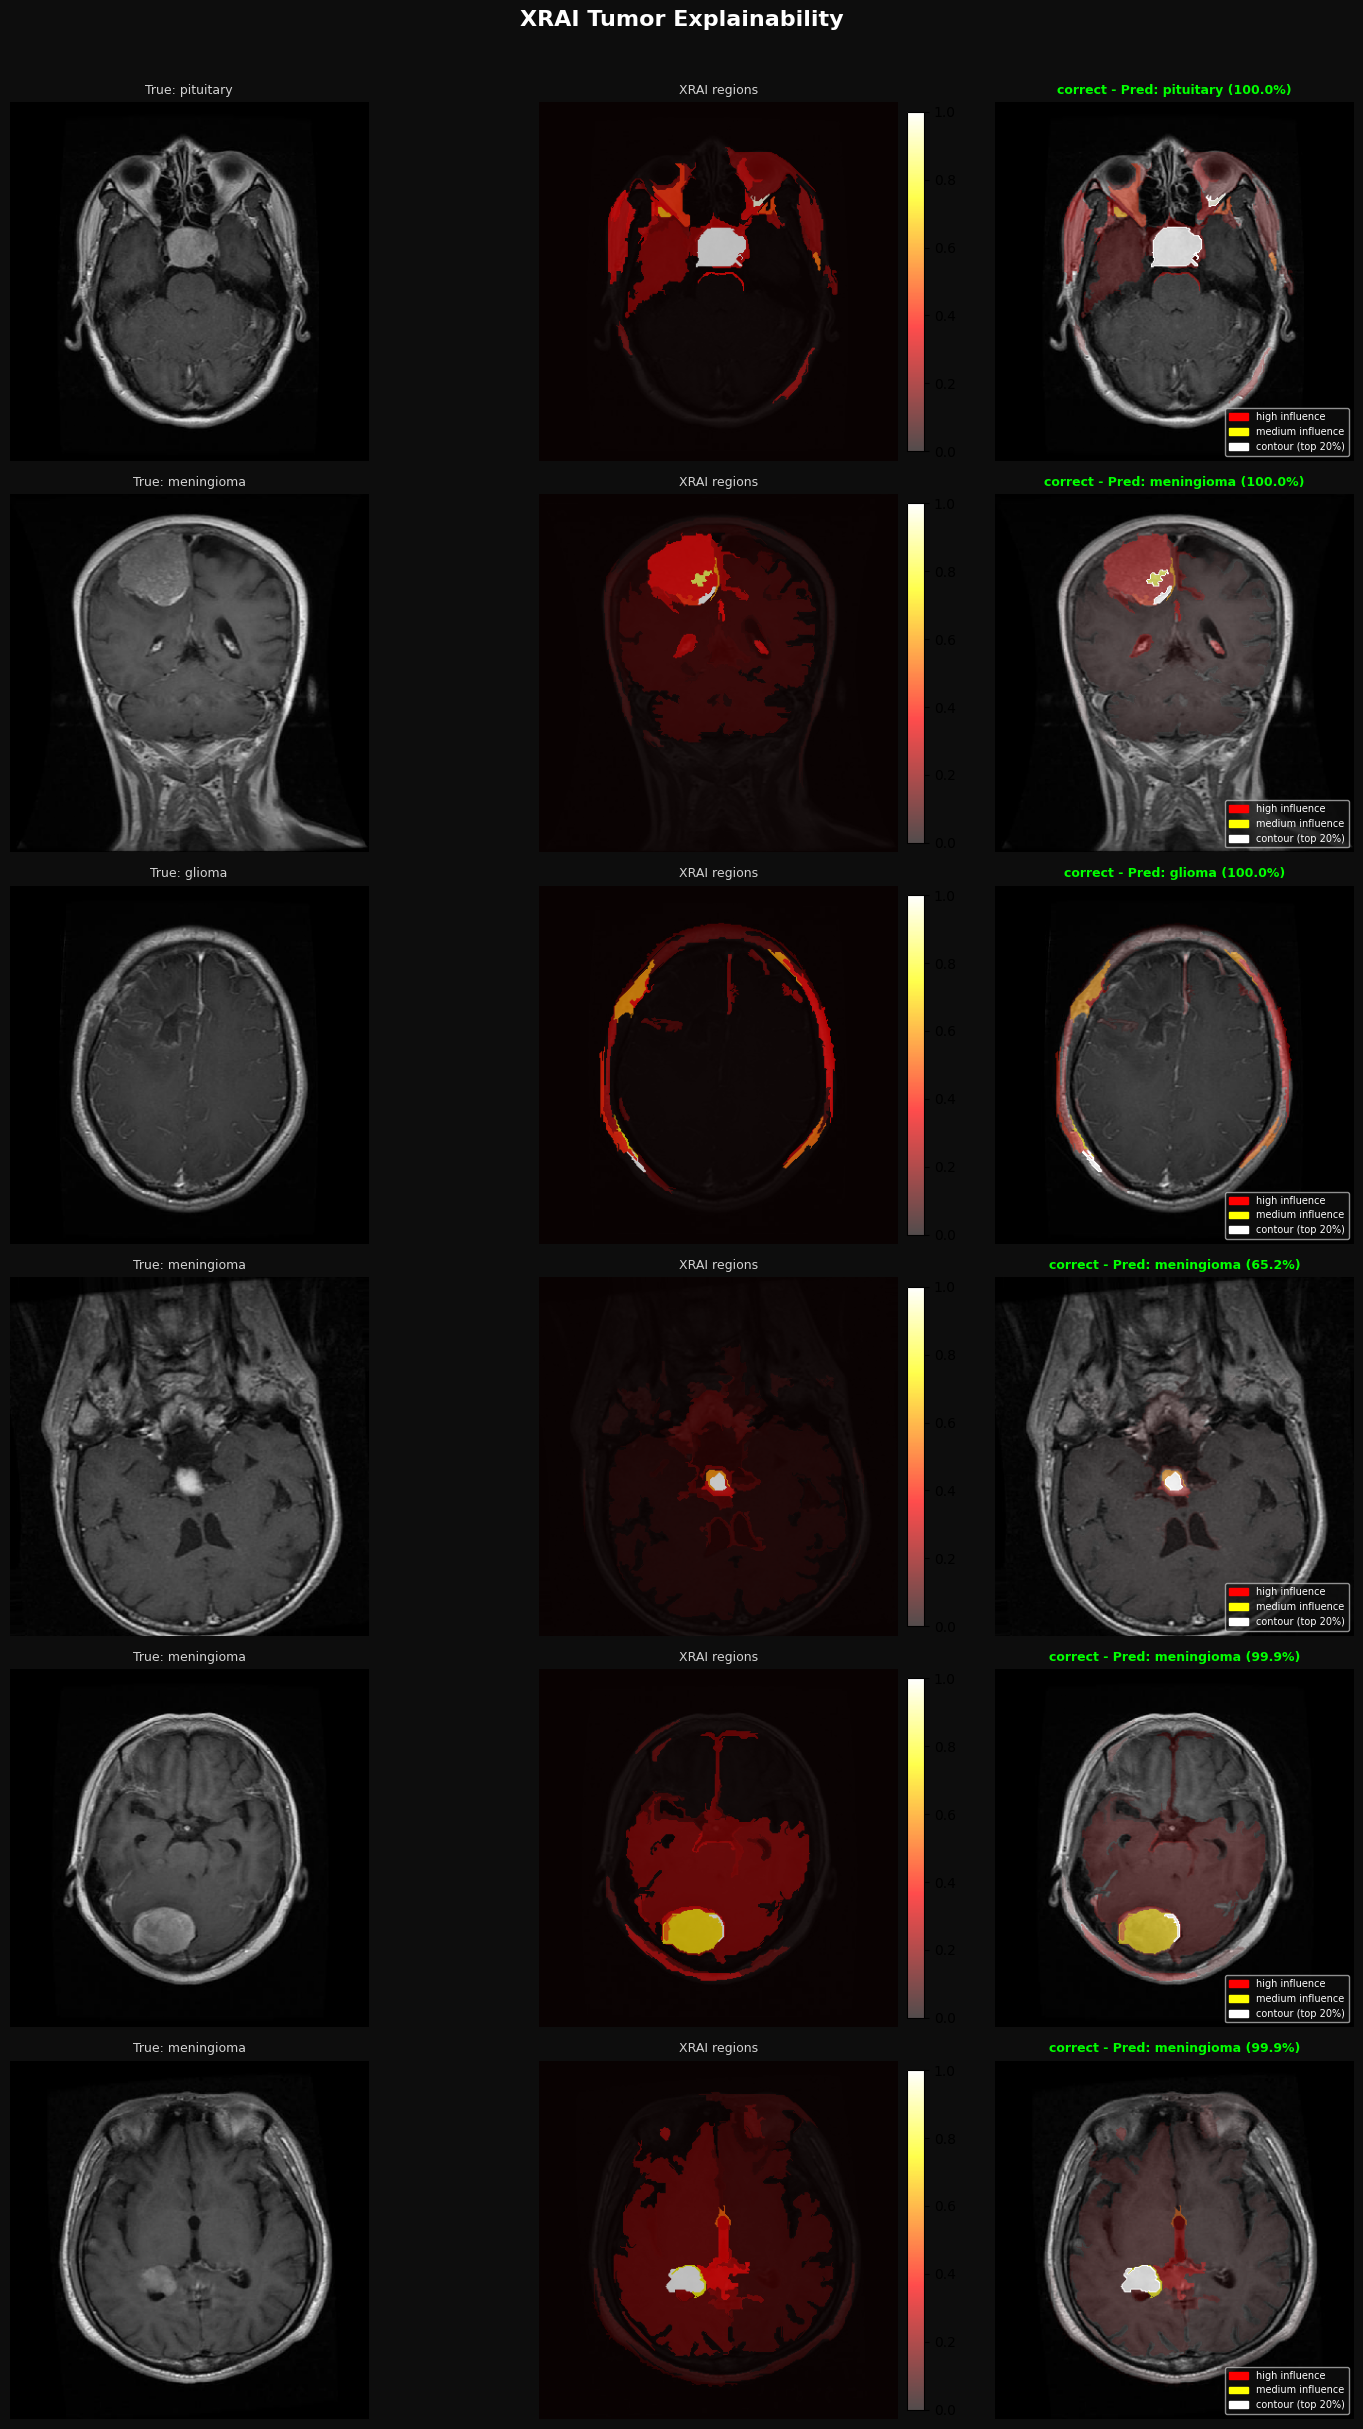

Saved: xrai_tumor_explainability.png


In [ ]:
# ========================================================
# 13 Model Explanation Using Superpixel Analysis (XRAI-like)
# ========================================================

NUM_IMAGES = 6
IMG_SIZE = (380, 380)

def integrated_gradients(model, img, class_index, baseline=None, steps=100):
    if baseline is None:
        baseline = np.zeros_like(img)

    img_tensor      = tf.convert_to_tensor(img[np.newaxis],      dtype=tf.float32)
    baseline_tensor = tf.convert_to_tensor(baseline[np.newaxis], dtype=tf.float32)
    alphas          = tf.linspace(0.0, 1.0, steps)
    total_grad      = tf.zeros_like(img_tensor)

    for alpha in alphas:
        interpolated = baseline_tensor + alpha * (img_tensor - baseline_tensor)
        interpolated = tf.Variable(interpolated)
        with tf.GradientTape() as tape:
            tape.watch(interpolated)
            preds = model(interpolated, training=False)
            score = preds[:, class_index]
        grads       = tape.gradient(score, interpolated)
        total_grad += grads

    avg_grad     = total_grad / steps
    attributions = (img_tensor - baseline_tensor) * avg_grad
    heatmap      = np.sum(np.abs(attributions.numpy()[0]), axis=-1)
    heatmap      = np.maximum(heatmap, 0)
    heatmap     /= np.max(heatmap) + 1e-8
    return heatmap


def xrai_like_map(img_array, heatmap, top_fraction=0.3):
    segments = felzenszwalb(
        (img_array * 255).astype(np.uint8),
        scale=150,
        sigma=0.8,
        min_size=80
    )
    region_scores = {
        label: np.mean(heatmap[segments == label])
        for label in np.unique(segments)
    }

    scores_arr = np.array(list(region_scores.values()))
    threshold  = np.percentile(scores_arr, (1 - top_fraction) * 100)

    xrai_map = np.zeros_like(heatmap)
    for label, score in region_scores.items():
        if score >= threshold:
            xrai_map[segments == label] = score

    mn, mx = xrai_map.min(), xrai_map.max()
    if mx > mn:
        xrai_map = (xrai_map - mn) / (mx - mn + 1e-8)

    return xrai_map, segments, region_scores


def overlay_tumor(img, xrai_map, alpha_max=0.70):
    heat_r  = cv2.resize(xrai_map, (img.shape[1], img.shape[0]))
    colored = plt.cm.hot(heat_r)[:, :, :3]

    alpha_map = (heat_r ** 0.6) * alpha_max
    alpha_3d  = alpha_map[:, :, np.newaxis]

    result    = colored * alpha_3d + img * (1 - alpha_3d)
    result    = np.clip(result, 0, 1)

    high_mask = (heat_r > 0.80).astype(np.uint8)
    contours  = measure.find_contours(high_mask, 0.5)
    result_u8 = (result * 255).astype(np.uint8)
    for contour in contours:
        pts = np.array([[int(p[1]), int(p[0])] for p in contour], dtype=np.int32)
        cv2.polylines(result_u8, [pts], isClosed=True,
                      color=(255, 255, 255), thickness=1)

    return result_u8.astype(np.float32) / 255.0


def textual_report(region_scores, num_top=5):
    sorted_regions = sorted(region_scores.items(), key=lambda x: x[1], reverse=True)
    total          = sum(s for _, s in sorted_regions) + 1e-8
    lines = []
    for i, (label, score) in enumerate(sorted_regions[:num_top]):
        pct      = score / total * 100
        priority = "high" if pct > 15 else ("medium" if pct > 8 else "low")
        lines.append(
            f"Region {i+1} (superpixel {label}): "
            f"influence {pct:.1f}% - priority {priority}"
        )
    return lines


all_preds        = model.predict(test_generator, verbose=0)
all_pred_classes = np.argmax(all_preds, axis=1)

tumor_indices = [
    idx for idx, lbl in enumerate(y_true)
    if class_labels[lbl].lower() != "notumor"
    and all_pred_classes[idx] == lbl
]

if len(tumor_indices) < NUM_IMAGES:
    print(f"Warning: only {len(tumor_indices)} valid tumor samples found, adjusting NUM_IMAGES.")
    NUM_IMAGES = len(tumor_indices)

selected = random.sample(tumor_indices, NUM_IMAGES)

fig, axes = plt.subplots(NUM_IMAGES, 3,
                         figsize=(15, NUM_IMAGES * 4),
                         facecolor='#0d0d0d')
fig.suptitle("XRAI Tumor Explainability", color='white',
             fontsize=16, fontweight='bold', y=1.01)

col_titles = ["Original Image", "XRAI Heatmap", "Overlay + Contour"]
for ax, ct in zip(axes[0], col_titles):
    ax.set_title(ct, color='white', fontsize=11, pad=8)

for i, idx in enumerate(selected):
    path     = test_generator.filepaths[idx]
    true_lbl = y_true[idx]

    img       = load_img(path, target_size=IMG_SIZE)
    img_array = img_to_array(img) / 255.0

    preds      = model.predict(np.expand_dims(img_array, 0), verbose=0)
    pred_class = np.argmax(preds[0])
    confidence = preds[0][pred_class] * 100

    heatmap                 = integrated_gradients(model, img_array, pred_class)
    xrai_map, segs, rscores = xrai_like_map(img_array, heatmap, top_fraction=0.3)
    out_img                 = overlay_tumor(img_array, xrai_map, alpha_max=0.70)

    ax0 = axes[i][0]
    ax0.imshow(img_array)
    ax0.set_title(f"True: {class_labels[true_lbl]}", color='lightgray', fontsize=9)
    ax0.axis('off')

    ax1 = axes[i][1]
    ax1.imshow(img_array, alpha=0.3)
    im = ax1.imshow(xrai_map, cmap='hot', alpha=0.7, vmin=0, vmax=1)
    ax1.set_title("XRAI regions", color='lightgray', fontsize=9)
    ax1.axis('off')
    plt.colorbar(im, ax=ax1, fraction=0.035, pad=0.02)

    ax2 = axes[i][2]
    ax2.imshow(out_img)
    ax2.set_title(
        f"correct - Pred: {class_labels[pred_class]} ({confidence:.1f}%)",
        color='lime', fontsize=9, fontweight='bold'
    )
    ax2.axis('off')

    patches = [
        mpatches.Patch(color='red',    label='high influence'),
        mpatches.Patch(color='yellow', label='medium influence'),
        mpatches.Patch(color='white',  label='contour (top 20%)'),
    ]
    ax2.legend(handles=patches, loc='lower right',
               fontsize=7, facecolor='#111', labelcolor='white',
               framealpha=0.7)

    fname = path.split('/')[-1]
    print(f"{'='*60}")
    print(f"File: {fname}")
    print(f"True label:  {class_labels[true_lbl]}")
    print(f"Predicted:   {class_labels[pred_class]} ({confidence:.1f}%)")
    print("Top regions:")
    for line in textual_report(rscores, num_top=5):
        print(f"  {line}")

plt.tight_layout()
plt.savefig("xrai_tumor_explainability.png",
            dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print("Saved: xrai_tumor_explainability.png")

,Image,True_Label,GradCAM_Score,XRAI_Score
0,Te-gl_1.jpg,glioma,0.482515,0.123903
1,Te-gl_10.jpg,glioma,0.482590,0.053476
2,Te-gl_100.jpg,glioma,0.484983,0.033112
3,Te-gl_101.jpg,glioma,0.439272,0.034576
4,Te-gl_102.jpg,glioma,0.456262,0.080207
5,Te-gl_103.jpg,glioma,0.449147,0.092239
6,Te-gl_104.jpg,glioma,0.445369,0.038873
7,Te-gl_105.jpg,glioma,0.461883,0.070163
8,Te-gl_106.jpg,glioma,0.445599,0.129671
9,Te-gl_107.jpg,glioma,0.465631,0.057843


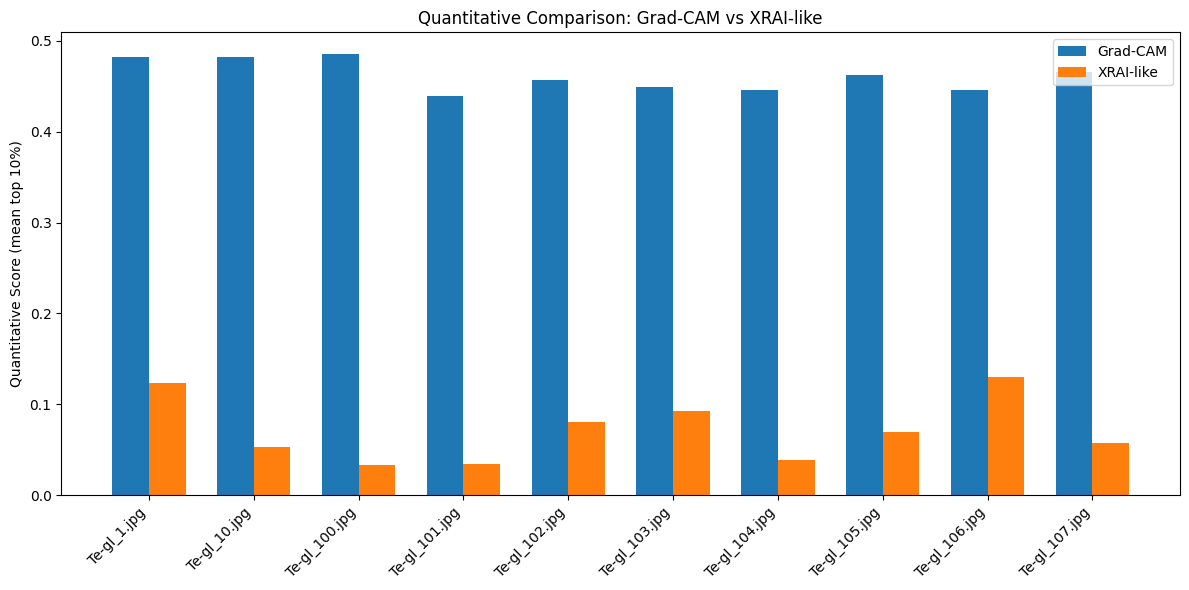

In [ ]:
# Helper function to get model branch (from aV1Xsc7-rnO6)
def get_branch(model_instance, name_keyword):
    for layer in model_instance.layers:
        if name_keyword.lower() in layer.name.lower():
            return layer
    raise ValueError(f"{name_keyword} branch not found in the model.")

# make_gradcam_heatmap_branch (modified from aV1Xsc7-rnO6 to work with model.input)
def make_gradcam_heatmap_branch_local(img_array_batch, branch, last_conv_layer_name, class_index=None):
    last_conv_layer = branch.get_layer(last_conv_layer_name)
    grad_model = tf.keras.models.Model(
        inputs=branch.input,
        outputs=[last_conv_layer.output, branch.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array_batch, training=False)

        if len(preds.shape) == 4: # If branch output is still spatial, e.g., EfficientNet without top
            preds_gap = tf.reduce_mean(preds, axis=(1, 2))
        else:
            preds_gap = preds

        if class_index is None:
            class_index = tf.argmax(preds_gap[0])
        class_channel = preds_gap[:, class_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0] # Get first image's conv outputs
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8
    return heatmap.numpy()

# Wrapper for Grad-CAM++ (using the Super Grad-CAM logic)
def gradcam_function(img_array, class_idx):
    img_batch = np.expand_dims(img_array, axis=0)

    # Assuming model, LAST_CONV_LAYER_RESNET, LAST_CONV_LAYER_EFF are globally defined
    resnet_branch = get_branch(model, "resnet")
    eff_branch = get_branch(model, "efficientnet")

    heatmap_resnet = make_gradcam_heatmap_branch_local(img_batch, resnet_branch, LAST_CONV_LAYER_RESNET, class_index=class_idx)
    heatmap_eff = make_gradcam_heatmap_branch_local(img_batch, eff_branch, LAST_CONV_LAYER_EFF, class_index=class_idx)

    # Combine heatmaps (average)
    return (heatmap_resnet + heatmap_eff) / 2

# integrated_gradients (from abCClFGDcUeI)
def integrated_gradients(model, img, class_index, baseline=None, steps=100):
    if baseline is None:
        baseline = np.zeros_like(img)

    img_tensor      = tf.convert_to_tensor(img[np.newaxis],      dtype=tf.float32)
    baseline_tensor = tf.convert_to_tensor(baseline[np.newaxis], dtype=tf.float32)
    alphas          = tf.linspace(0.0, 1.0, steps)
    total_grad      = tf.zeros_like(img_tensor)

    for alpha in alphas:
        interpolated = baseline_tensor + alpha * (img_tensor - baseline_tensor)
        interpolated = tf.Variable(interpolated)
        with tf.GradientTape() as tape:
            tape.watch(interpolated)
            preds = model(interpolated, training=False)
            score = preds[:, class_index]
        grads       = tape.gradient(score, interpolated)
        total_grad += grads

    avg_grad     = total_grad / steps
    attributions = (img_tensor - baseline_tensor) * avg_grad
    heatmap      = np.sum(np.abs(attributions.numpy()[0]), axis=-1)
    heatmap      = np.maximum(heatmap, 0)
    heatmap     /= np.max(heatmap) + 1e-8
    return heatmap

# xrai_function (wrapper for integrated_gradients)
def xrai_function(img_array, class_idx):
    # XRAI typically uses Integrated Gradients as its base explanation map
    return integrated_gradients(model, img_array, class_idx)

# Quantitative comparison
comparison_results = []

NUM_IMAGES = 10

for i in range(NUM_IMAGES):
    img_path = test_generator.filepaths[i]
    true_label = y_true[i]
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)/255.0

    # Predict class for this image
    img_batch = np.expand_dims(img_array, axis=0)
    preds = model.predict(img_batch, verbose=0)
    pred_class = np.argmax(preds[0])

    # Grad-CAM
    gradcam_map = gradcam_function(img_array, pred_class) # Pass pred_class
    gradcam_score = np.mean(np.sort(gradcam_map.flatten())[-int(0.1*gradcam_map.size):])

    # XRAI-like
    xrai_map = xrai_function(img_array, pred_class) # Pass pred_class
    xrai_score = np.mean(np.sort(xrai_map.flatten())[-int(0.1*xrai_map.size):])

    comparison_results.append({
        "Image": img_path.split('/')[-1],
        "True_Label": class_labels[true_label],
        "GradCAM_Score": gradcam_score,
        "XRAI_Score": xrai_score
    })

# Create DataFrame
df_comparison = pd.DataFrame(comparison_results)
display(df_comparison)

# Plot bar chart for comparison
plt.figure(figsize=(12,6))
bar_width = 0.35
indices = np.arange(len(df_comparison))

plt.bar(indices, df_comparison["GradCAM_Score"], bar_width, label="Grad-CAM")
plt.bar(indices+bar_width, df_comparison["XRAI_Score"], bar_width, label="XRAI-like")
plt.xticks(indices+bar_width/2, df_comparison["Image"], rotation=45, ha="right")
plt.ylabel("Quantitative Score (mean top 10%)")
plt.title("Quantitative Comparison: Grad-CAM vs XRAI-like")
plt.legend()
plt.tight_layout()
plt.show()